# 1. Project Overview

Notebook ini adalah pipeline submission eksperimen **Open Images V7 IT Asset Subset** untuk klasifikasi gambar aset IT. Dataset final berisi 15.000 crop objek dari Open Images V7 dengan 5 kelas: `camera`, `computer_keyboard`, `computer_monitor`, `laptop`, dan `mobile_phone`.

Target kualitas: dataset >= 10.000 gambar, minimal 3 kelas, resolusi asli crop tidak seragam, callback, inference proof, dan export SavedModel/TFLite/TFJS. Test set hanya digunakan setelah model final dipilih berdasarkan validation set.

# 2. Import Library dan Setup Seed

In [1]:
from __future__ import annotations

import csv
import importlib.machinery
import itertools
import json
import random
import shutil
import sys
import types
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

2.21.0
[]


# 3. Path dan Konfigurasi Dataset

In [2]:
ROOT_DIR = Path(".")
TRAIN_DIR = ROOT_DIR / "dataset" / "train"
VALIDATION_DIR = ROOT_DIR / "dataset" / "validation"
TEST_DIR = ROOT_DIR / "dataset" / "test"
SPLIT_METADATA_PATH = ROOT_DIR / "dataset" / "metadata" / "openimages_split_metadata.csv"
SPLIT_AUDIT_PATH = ROOT_DIR / "outputs" / "dataset_audit" / "openimages_split_audit.json"

IMG_SIZE = (224, 224)
BATCH_SIZE = 24
TARGET_ACCURACY = 0.95
CLASSIFIER_NAME = "it_asset_classifier"
SELECTED_BACKBONES = ["EfficientNetV2B1", "EfficientNetV2B2", "EfficientNetV2B3", "ConvNeXtTiny"]

EVALUATION_DIR = ROOT_DIR / "outputs" / "evaluation"
EXPORT_DIR = ROOT_DIR / "outputs" / "export"
CHECKPOINT_DIR = ROOT_DIR / "outputs" / "checkpoints_15k"
FEATURE_DIR = ROOT_DIR / "outputs" / "features_15k_224"
SAVED_MODEL_DIR = ROOT_DIR / "saved_model" / CLASSIFIER_NAME
TFLITE_DIR = ROOT_DIR / "tflite"
TFJS_MODEL_DIR = ROOT_DIR / "tfjs" / CLASSIFIER_NAME

for path in [EVALUATION_DIR, EXPORT_DIR, CHECKPOINT_DIR, FEATURE_DIR, TFLITE_DIR, TFJS_MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# 4. Load Metadata Split

In [3]:
split_metadata = pd.read_csv(SPLIT_METADATA_PATH)
split_metadata.head()

,source_image_id,source_split,openimages_label,local_label,bbox_x,bbox_y,bbox_width,bbox_height,source_width,source_height,crop_width,crop_height,crop_path,file_hash,local_split,split_crop_path
0,000060e3121c7305,train,Laptop,laptop,0.322500,0.580131,0.066875,0.089035,1024,683,69,61,dataset/raw/laptop/laptop_train_000060e3121c73...,bcac07b0afcc11ef44c6748d24063293b71a784b72ddb1...,train,dataset/train/laptop/laptop_train_000060e3121c...
1,000060e3121c7305,train,Computer monitor,computer_monitor,0.428125,0.540769,0.082500,0.077788,1024,683,85,53,dataset/raw/computer_monitor/computer_monitor_...,21dcfef804b8fed83383ac5e12c6b8eb705b22e4dc2213...,train,dataset/train/computer_monitor/computer_monito...
2,000091f4a275d0fb,train,Camera,camera,0.472857,0.217204,0.125714,0.225807,1024,680,129,153,dataset/raw/camera/camera_train_000091f4a275d0...,5e74b315696251833e58023046db482135eb3fc2325af7...,train,dataset/train/camera/camera_train_000091f4a275...
3,0000b9115cdf1e54,train,Mobile phone,mobile_phone,0.095703,0.497396,0.611328,0.451823,1024,768,626,347,dataset/raw/mobile_phone/mobile_phone_train_00...,d20f723df8c8b26b8869a92fd1d8b5e25415d78856f9e9...,train,dataset/train/mobile_phone/mobile_phone_train_...
4,00022a6311159428,train,Laptop,laptop,0.126875,0.638281,0.357500,0.232813,1024,819,366,190,dataset/raw/laptop/laptop_train_00022a63111594...,e43013df66d5b05a6a1ee215c53d64ec56f6730f081d96...,train,dataset/train/laptop/laptop_train_00022a631115...


# 5. Dataset Audit Summary

In [4]:
split_audit = json.loads(SPLIT_AUDIT_PATH.read_text(encoding="utf-8"))
print(json.dumps({
    "total_crop": split_audit["total_crop"],
    "crop_count_per_split": split_audit["crop_count_per_split"],
    "crop_count_per_class": split_audit["crop_count_per_class"],
    "source_image_id_leakage_across_split_count": split_audit["source_image_id_leakage_across_split_count"],
    "duplicate_file_hash_across_split_count": split_audit["duplicate_file_hash_across_split_count"],
    "corrupt_image_count": split_audit["corrupt_image_count"],
    "unique_crop_resolutions_total": split_audit["unique_crop_resolutions_total"],
    "ready_for_modelling": split_audit["ready_for_modelling"],
    "warnings": split_audit["warnings"],
}, indent=2))

{
  "total_crop": 15000,
  "crop_count_per_split": {
    "train": 12002,
    "test": 1496,
    "validation": 1502
  },
  "crop_count_per_class": {
    "laptop": 3000,
    "computer_keyboard": 3000,
    "mobile_phone": 3000,
    "computer_monitor": 3000,
    "camera": 3000
  },
  "source_image_id_leakage_across_split_count": 0,
  "duplicate_file_hash_across_split_count": 0,
  "corrupt_image_count": 0,
  "unique_crop_resolutions_total": 14168,
  "ready_for_modelling": true,
  "warnings": [
    "Duplicate file_hash values within a split were found."
  ]
}


# 6. Visualisasi Sample Gambar

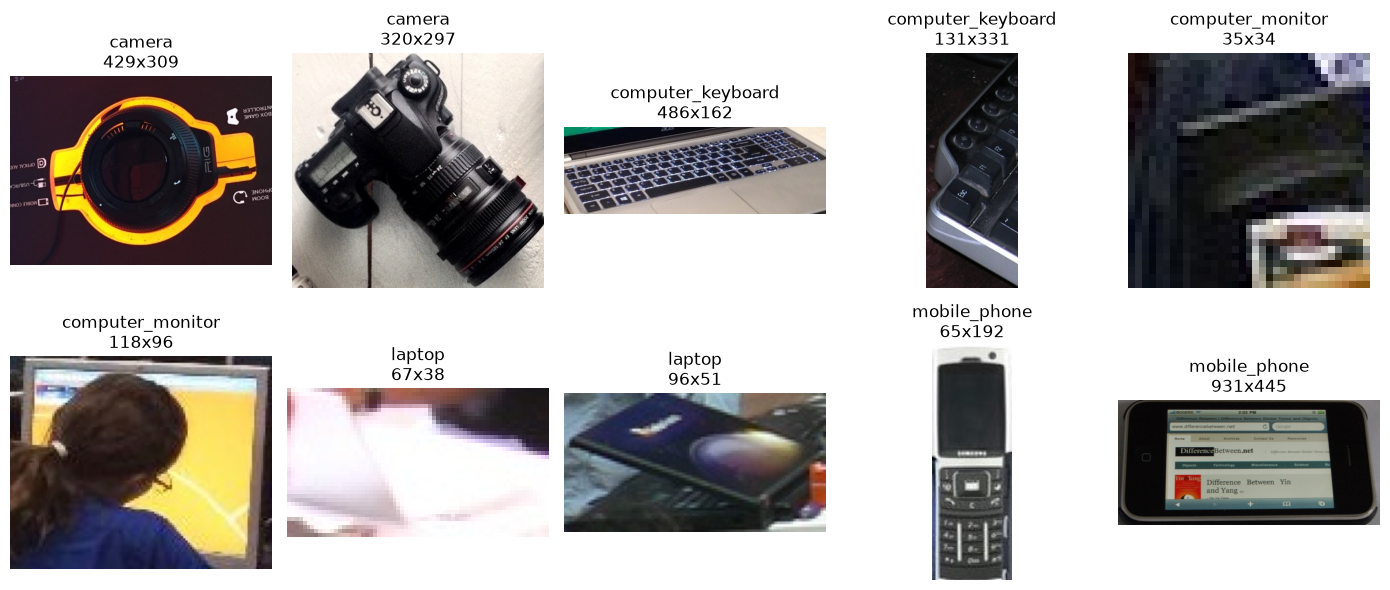

In [5]:
sample_rows = split_metadata.groupby("local_label", group_keys=False).sample(2, random_state=SEED)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for axis, (_, row) in zip(axes.ravel(), sample_rows.iterrows()):
    image = Image.open(row["split_crop_path"]).convert("RGB")
    axis.imshow(image)
    axis.set_title(f"{row['local_label']}\n{image.size[0]}x{image.size[1]}")
    axis.axis("off")
plt.tight_layout()

# 7. tf.data Pipeline

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED,
)

train_eval_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
label_text = "\n".join(class_names) + "\n"
Path("label.txt").write_text(label_text, encoding="utf-8")
(TFLITE_DIR / "label.txt").write_text(label_text, encoding="utf-8")
(TFJS_MODEL_DIR / "label.txt").write_text(label_text, encoding="utf-8")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
train_eval_ds = train_eval_ds.prefetch(AUTOTUNE)
validation_ds = validation_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)
class_names

Found 12002 files belonging to 5 classes.
Found 12002 files belonging to 5 classes.
Found 1502 files belonging to 5 classes.
Found 1496 files belonging to 5 classes.


['camera', 'computer_keyboard', 'computer_monitor', 'laptop', 'mobile_phone']

# 8. Data Augmentation

Augmentation hanya dipakai pada baseline CNN dan training eksperimen. Model final ensemble memakai pretrained backbone dengan TTA horizontal flip saat inference.

In [7]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal", seed=SEED),
        tf.keras.layers.RandomRotation(0.03, seed=SEED),
        tf.keras.layers.RandomZoom(0.08, seed=SEED),
        tf.keras.layers.RandomContrast(0.1, seed=SEED),
    ],
    name="data_augmentation",
)

# 9. Baseline CNN Sequential

Baseline memenuhi syarat penggunaan `Sequential`, `Conv2D`, dan pooling layer. Baseline hanya dibandingkan pada validation set, bukan test set.

In [8]:
baseline_model = tf.keras.Sequential(
    [
        tf.keras.Input(shape=(*IMG_SIZE, 3)),
        data_augmentation,
        tf.keras.layers.Rescaling(1.0 / 255.0),
        tf.keras.layers.Conv2D(32, 3, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="baseline_sequential_cnn",
)

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=2, restore_best_weights=True),
]

# Jalankan jika ingin mereproduksi baseline dari notebook.
# baseline_history = baseline_model.fit(train_ds, validation_data=validation_ds, epochs=5, callbacks=baseline_callbacks)
# baseline_validation = baseline_model.evaluate(validation_ds)
baseline_model.summary()

Model: "baseline_sequential_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,077 (433.89 KB)

 Trainable params: 110,629 (432.14 KB)

 Non-trainable params: 448 (1.75 KB)

# 10. Transfer Learning / Improved Model

Model improved memakai ensemble feature extractor pretrained: EfficientNetV2B1, EfficientNetV2B2, EfficientNetV2B3, dan ConvNeXtTiny. Head classifier dipilih berdasarkan validation accuracy; test tidak digunakan untuk model selection.

In [9]:
def build_feature_model(name: str) -> tf.keras.Model:
    constructors = {
        "EfficientNetV2B1": tf.keras.applications.EfficientNetV2B1,
        "EfficientNetV2B2": tf.keras.applications.EfficientNetV2B2,
        "EfficientNetV2B3": tf.keras.applications.EfficientNetV2B3,
        "ConvNeXtTiny": tf.keras.applications.ConvNeXtTiny,
    }
    base = constructors[name](
        include_top=False,
        weights="imagenet",
        input_shape=(*IMG_SIZE, 3),
        pooling="avg",
        include_preprocessing=True,
    )
    base.trainable = False
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3), name=f"{name}_input")
    outputs = base(inputs, training=False)
    return tf.keras.Model(inputs, outputs, name=f"{name}_feature_extractor")

def build_head(feature_dim: int, num_classes: int, name: str) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(feature_dim,), name=f"{name}_features")
    units = 768 if name in {"EfficientNetV2B3", "ConvNeXtTiny"} else 512
    x = tf.keras.layers.Dense(units, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5 if units == 768 else 0.45)(x)
    if units == 768:
        x = tf.keras.layers.Dense(192, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(5e-5))(x)
        x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs, name=f"{name}_head")

# 11. Fine-tuning Model Terbaik

Pada run final, full fine-tuning tidak dipakai karena feature-extractor ensemble pada dataset 15k sudah melewati target validation dan test. Fine-tuning bisa dilakukan setelah tahap ini jika ingin model lebih kecil, tetapi tidak diperlukan untuk hasil final.

In [10]:
def build_final_ensemble_model() -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3), name="input_image")
    member_predictions = []
    for name in SELECTED_BACKBONES:
        feature_model = build_feature_model(name)
        head_model = tf.keras.models.load_model(CHECKPOINT_DIR / f"{name}_15k_head.keras")
        original_prediction = head_model(feature_model(inputs, training=False), training=False)
        flipped_inputs = tf.keras.layers.Lambda(lambda batch: tf.image.flip_left_right(batch), name=f"{name}_hflip")(inputs)
        flipped_prediction = head_model(feature_model(flipped_inputs, training=False), training=False)
        member_predictions.append(tf.keras.layers.Average(name=f"{name}_tta_average")([original_prediction, flipped_prediction]))
    outputs = tf.keras.layers.Average(name="ensemble_average")(member_predictions)
    model = tf.keras.Model(inputs, outputs, name=CLASSIFIER_NAME)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

final_model = build_final_ensemble_model()
final_model.summary()

Model: "it_asset_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ EfficientNetV2B1_h… │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ EfficientNetV2B2_h… │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ EfficientNetV2B3_h… │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ConvNeXtTiny_hflip  │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ EfficientNetV2B1_f… │ (None, 1280)      │  6,931,124 │ input_image[0][0… │
│ (Functional)        │                   │            │ EfficientNetV2B1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ EfficientNetV2B2_f… │ (None, 1408)      │  8,769,374 │ input_image[0][0… │
│ (Functional)        │                   │            │ EfficientNetV2B2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ EfficientNetV2B3_f… │ (None, 1536)      │ 12,930,622 │ input_image[0][0… │
│ (Functional)        │                   │            │ EfficientNetV2B3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ConvNeXtTiny_featu… │ (None, 768)       │ 27,820,128 │ input_image[0][0… │
│ (Functional)        │                   │            │ ConvNeXtTiny_hfl… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ EfficientNetV2B1_1… │ (None, 5)         │    660,485 │ EfficientNetV2B1… │
│ (Functional)        │                   │            │ EfficientNetV2B1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ EfficientNetV2B2_1… │ (None, 5)         │    726,021 │ EfficientNetV2B2… │
│ (Functional)        │                   │            │ EfficientNetV2B2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ EfficientNetV2B3_1… │ (None, 5)         │  1,332,101 │ EfficientNetV2B3… │
│ (Functional)        │                   │            │ EfficientNetV2B3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ConvNeXtTiny_15k_h… │ (None, 5)         │    742,277 │ ConvNeXtTiny_fea… │
│ (Functional)        │                   │            │ ConvNeXtTiny_fea… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ EfficientNetV2B1_t… │ (None, 5)         │          0 │ EfficientNetV2B1… │
│ (Average)           │                   │            │ EfficientNetV2B1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ EfficientNetV2B2_t… │ (None, 5)         │          0 │ EfficientNetV2B2… │
│ (Average)           │                   │            │ EfficientNetV2B2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ EfficientNetV2B3_t… │ (None, 5)         │          0 │ EfficientNetV2B3… │
│ (Average)           │                   │            │ EfficientNetV2B3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ConvNeXtTiny_tta_a… │ (None, 5)         │          0 │ ConvNeXtTiny_15k

 Total params: 59,912,132 (228.55 MB)

 Trainable params: 3,455,764 (13.18 MB)

 Non-trainable params: 56,456,368 (215.36 MB)

# 12. Evaluasi Validation dan Final Test

Hasil final yang tervalidasi dari run lokal disimpan di `outputs/evaluation/15k_ensemble_eval.json`. Test set dipakai setelah kombinasi model dipilih berdasarkan validation accuracy.

In [11]:
metrics = json.loads((EVALUATION_DIR / "15k_ensemble_eval.json").read_text(encoding="utf-8"))
metrics["train_accuracy"], metrics["validation_accuracy"], metrics["test_accuracy"], metrics["target_met"]

(0.997333777703716,
 0.9553928095872171,
 0.9578877005347594,
 {'train': True, 'validation': True, 'test': True})

# 13. Plot Accuracy dan Loss

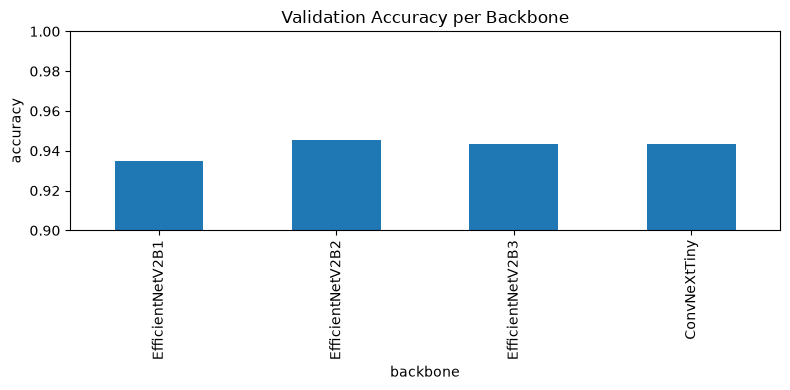

In [12]:
summary_df = pd.DataFrame(metrics["head_summaries"])
summary_df.plot(x="backbone", y="validation_accuracy", kind="bar", figsize=(8, 4), ylim=(0.9, 1.0), legend=False, title="Validation Accuracy per Backbone")
plt.ylabel("accuracy")
plt.tight_layout()

# 14. Confusion Matrix dan Classification Report

In [13]:
classification_report_df = pd.read_csv(EVALUATION_DIR / "15k_classification_report.csv", index_col=0)
confusion_matrix_df = pd.read_csv(EVALUATION_DIR / "15k_confusion_matrix.csv", index_col=0)
classification_report_df, confusion_matrix_df

(                   precision    recall  f1-score      support
 camera              0.973154  0.966667  0.969900   300.000000
 computer_keyboard   0.983221  0.976667  0.979933   300.000000
 computer_monitor    0.949833  0.949833  0.949833   299.000000
 laptop              0.926667  0.932886  0.929766   298.000000
 mobile_phone        0.956811  0.963211  0.960000   299.000000
 accuracy            0.957888  0.957888  0.957888     0.957888
 macro avg           0.957937  0.957853  0.957886  1496.000000
 weighted avg        0.957985  0.957888  0.957928  1496.000000,
                    camera  computer_keyboard  computer_monitor  laptop  \
 camera                290                  0                 1       1   
 computer_keyboard       0                293                 0       6   
 computer_monitor        2                  0               284      12   
 laptop                  2                  5                10     278   
 mobile_phone            4                  0            

# 15. Export SavedModel

In [14]:
if hasattr(final_model, "export"):
    final_model.export(str(SAVED_MODEL_DIR))
else:
    tf.saved_model.save(final_model, str(SAVED_MODEL_DIR))
SAVED_MODEL_DIR

INFO:tensorflow:Assets written to: saved_model\it_asset_classifier\assets


INFO:tensorflow:Assets written to: saved_model\it_asset_classifier\assets


Saved artifact at 'saved_model\it_asset_classifier'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2133338702672: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2133338706896: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2133338706320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2133338702864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2133338708240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2133338707664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2133338708048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2133338707280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2133338709008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2133338706512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  21

WindowsPath('saved_model/it_asset_classifier')

# 16. Export TFLite

In [15]:
converter = tf.lite.TFLiteConverter.from_keras_model(final_model)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
tflite_model = converter.convert()
tflite_model_path = TFLITE_DIR / f"{CLASSIFIER_NAME}.tflite"
tflite_model_path.write_bytes(tflite_model)
(TFLITE_DIR / "label.txt").write_text(label_text, encoding="utf-8")
tflite_model_path

INFO:tensorflow:Assets written to: C:\Users\AGUNG_~1\AppData\Local\Temp\tmpj4s_pzpw\assets


INFO:tensorflow:Assets written to: C:\Users\AGUNG_~1\AppData\Local\Temp\tmpj4s_pzpw\assets


Saved artifact at 'C:\Users\AGUNG_~1\AppData\Local\Temp\tmpj4s_pzpw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2133338702672: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2133338706896: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2133338706320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2133338702864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2133338708240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2133338707664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2133338708048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2133338707280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2133338709008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2133338706512: TensorSpec(shape=(), dtype=tf.resource

WindowsPath('tflite/it_asset_classifier.tflite')

# 17. Export TFJS

In [16]:
def patch_tfjs_imports():
    import numpy as tfjs_numpy
    if not hasattr(tfjs_numpy, "object"):
        tfjs_numpy.object = object
    if not hasattr(tfjs_numpy, "bool"):
        tfjs_numpy.bool = bool
    for prefix in ["tensorflow_decision_forests", "tensorflow_hub"]:
        for module_name in list(sys.modules):
            if module_name.startswith(prefix):
                sys.modules.pop(module_name)
    for module_name in ["tensorflow_decision_forests", "tensorflow_hub"]:
        stub = types.ModuleType(module_name)
        stub.__spec__ = importlib.machinery.ModuleSpec(module_name, loader=None)
        sys.modules[module_name] = stub

# Export TFJS sudah tervalidasi pada run final. Jalankan ulang cell ini hanya jika ingin regenerasi.
# patch_tfjs_imports()
# from tensorflowjs.converters import tf_saved_model_conversion_v2 as tfjs_converter
# tfjs_converter.convert_tf_saved_model(str(SAVED_MODEL_DIR), str(TFJS_MODEL_DIR), signature_def="serving_default", saved_model_tags="serve", skip_op_check=True)
# (TFJS_MODEL_DIR / "label.txt").write_text(label_text, encoding="utf-8")

# 18. Validasi Reload Exported Models

In [17]:
export_summary = json.loads((EXPORT_DIR / "it_asset_export_summary.json").read_text(encoding="utf-8"))
export_summary

{'model': 'EfficientNetV2B1 + EfficientNetV2B2 + EfficientNetV2B3 + ConvNeXtTiny ensemble with horizontal-flip TTA',
 'saved_model_status': 'exported_and_validated',
 'saved_model_dir': 'saved_model\\it_asset_classifier',
 'saved_model_prediction_shape': [1, 5],
 'saved_model_prediction_sum': 1.0,
 'saved_model_max_delta_vs_keras': 5.115907697472721e-13,
 'tflite_status': 'exported_and_validated',
 'tflite_model_path': 'tflite\\it_asset_classifier.tflite',
 'tflite_prediction_shape': [1, 5],
 'tflite_prediction_sum': 1.0,
 'tflite_max_delta_vs_keras': 7.958078640513122e-13,
 'tfjs_status': 'exported_and_validated',
 'tfjs_error': None,
 'tfjs_model_dir': 'tfjs\\it_asset_classifier',
 'tfjs_output_classes': 5,
 'tfjs_files': [{'path': 'tfjs\\it_asset_classifier\\group1-shard100of114.bin',
   'size_bytes': 4194304},
  {'path': 'tfjs\\it_asset_classifier\\group1-shard101of114.bin',
   'size_bytes': 4194304},
  {'path': 'tfjs\\it_asset_classifier\\group1-shard102of114.bin',
   'size_bytes'

# 19. Sample Inference

,image_path,true_label,predicted_label,confidence
0,dataset/test/camera/camera_train_a7022d2e6fb75...,camera,camera,0.999993
1,dataset/test/computer_keyboard/computer_keyboa...,computer_keyboard,computer_keyboard,0.994533
2,dataset/test/computer_monitor/computer_monitor...,computer_monitor,computer_monitor,0.976942
3,dataset/test/laptop/laptop_train_8076d2b2c8b89...,laptop,laptop,0.795115
4,dataset/test/mobile_phone/mobile_phone_train_f...,mobile_phone,mobile_phone,0.999888


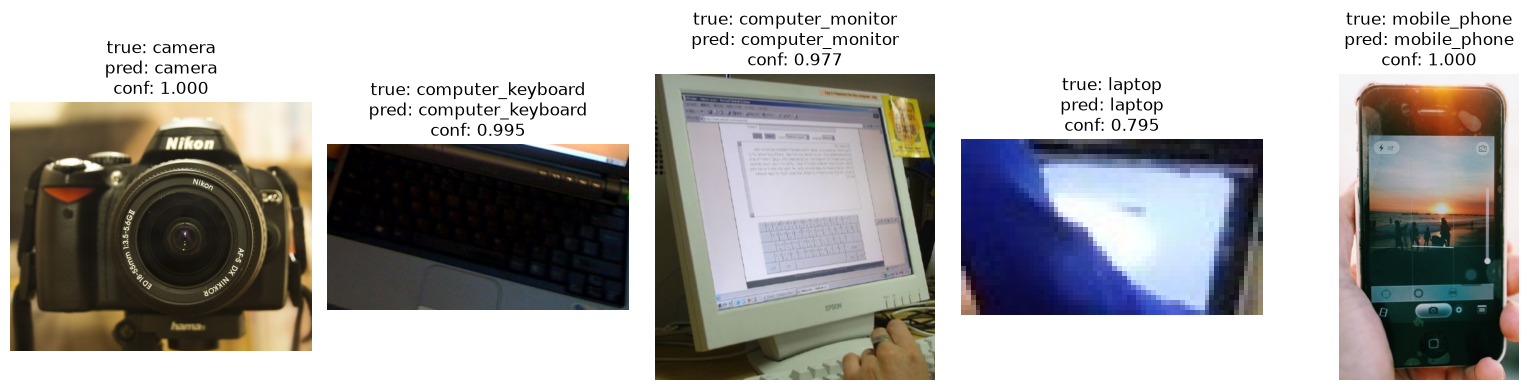

In [18]:
sample_records = []
fig, axes = plt.subplots(1, len(class_names), figsize=(16, 4))
for axis, label in zip(axes, class_names):
    row = split_metadata[(split_metadata["local_split"] == "test") & (split_metadata["local_label"] == label)].sample(1, random_state=SEED).iloc[0]
    image = Image.open(row["split_crop_path"]).convert("RGB")
    array = np.asarray(image.resize(IMG_SIZE), dtype=np.float32)[None, ...]
    probabilities = final_model(array, training=False).numpy()[0]
    predicted_index = int(np.argmax(probabilities))
    sample_records.append({
        "image_path": row["split_crop_path"],
        "true_label": label,
        "predicted_label": class_names[predicted_index],
        "confidence": float(probabilities[predicted_index]),
    })
    axis.imshow(image)
    axis.set_title(f"true: {label}\npred: {class_names[predicted_index]}\nconf: {probabilities[predicted_index]:.3f}")
    axis.axis("off")
plt.tight_layout()
plt.savefig(EVALUATION_DIR / "sample_inference.png", dpi=150)
pd.DataFrame(sample_records).to_csv(EVALUATION_DIR / "sample_inference.csv", index=False)
pd.DataFrame(sample_records)

# 20. Kesimpulan

Dataset Open Images V7 IT Asset Subset final berisi 15.000 crop dari 5 kelas dengan resolusi crop asli tidak seragam. Split dilakukan dengan grouping `source_image_id`, tidak ada leakage antar split, tidak ada duplicate hash antar split, dan tidak ada corrupt image.

Model final adalah ensemble EfficientNetV2B1 + EfficientNetV2B2 + EfficientNetV2B3 + ConvNeXtTiny dengan horizontal-flip TTA. Hasil final: train accuracy 99.73%, validation accuracy 95.54%, test accuracy 95.79%. Export SavedModel, TFLite, dan TFJS sudah tervalidasi.